<a href="https://colab.research.google.com/github/RCalvoso/grupo4_projeto_integrador_2/blob/main/01_Exploracao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os

# 1. Clonar o repositório do grupo (se ainda não tiver sido clonado na sessão atual)
repo_name = "grupo4_projeto_integrador_2"
if not os.path.exists(repo_name):
    !git clone https://github.com/RCalvoso/grupo4_projeto_integrador_2.git

# 2. Entrar na pasta raiz do repositório
%cd /content/grupo4_projeto_integrador_2

# 3. Confirmar a pasta atual e verificar se os arquivos/datasets estão acessíveis
print("\nDiretório atual:", os.getcwd())
print("Arquivos no repositório:", os.listdir('.'))

Cloning into 'grupo4_projeto_integrador_2'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), done.
Resolving deltas: 100% (1/1), done.
/content/grupo4_projeto_integrador_2

Diretório atual: /content/grupo4_projeto_integrador_2
Arquivos no repositório: ['.gitignore', 'README.md', 'notebooks', '.git']


✅ Arquivo localizado em: /content/drive/MyDrive/Especialização em Inteligência Artificial PUC-SP 2026/Módulo 2/Projeto Integrador II -Aplicação de Deep Learning/dataset/chamados.csv

Dataset carregado com sucesso: 5000 linhas e 44 colunas.

=== Top 15 Colunas com Maior Volume de Dados Faltantes ===
                    Nulos  Porcentagem (%)
last_event_date      5000           100.00
event_types          5000           100.00
num_images_y         5000           100.00
monthly_revenue      4998            99.96
contract_type        4998            99.96
employees            4998            99.96
city_y               4998            99.96
segment              4998            99.96
company              4998            99.96
vip                  4998            99.96
customer_since       4998            99.96
state_y              4998            99.96
sla_hours               0             0.00
historical_tickets      0             0.00
network_type            0             0.00


/tmp/ipykernel_578/903385718.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_category', palette='viridis')


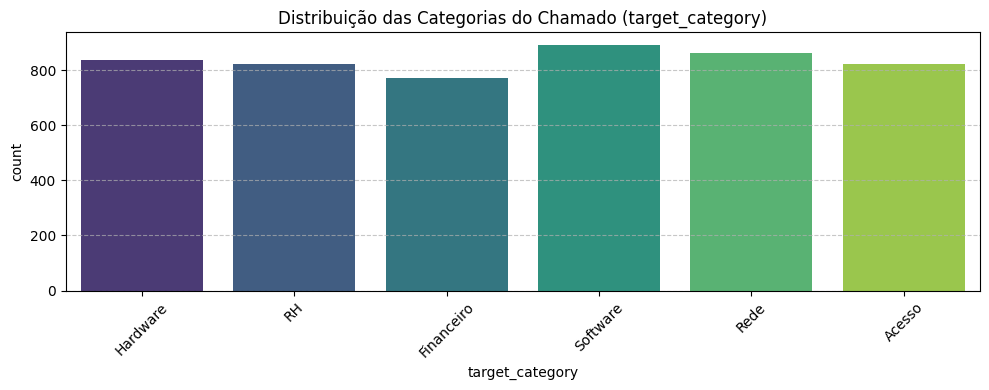


=== Verificação dos Dados Multimodais ===
Chamados com caminho de imagem: 5000 de 5000
Tamanho médio dos títulos: 53.6 caracteres
Tamanho médio das descrições: 54.5 caracteres


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Garantir que o Drive está montado
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Localizar o arquivo chamados.csv dinamicamente no Drive
file_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'chamados.csv' in files:
        file_path = os.path.join(root, 'chamados.csv')
        break

if file_path:
    print(f"✅ Arquivo localizado em: {file_path}\n")
    # 3. Carregar o dataset
    df = pd.read_csv(file_path)
    print(f"Dataset carregado com sucesso: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

    # 4. Diagnóstico de Dados Ausentes
    null_summary = pd.DataFrame({
        'Nulos': df.isnull().sum(),
        'Porcentagem (%)': (df.isnull().sum() / len(df)) * 100
    }).sort_values(by='Porcentagem (%)', ascending=False)

    print("=== Top 15 Colunas com Maior Volume de Dados Faltantes ===")
    print(null_summary.head(15))

    # 5. Distribuição da Variável Alvo (target_category)
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x='target_category', palette='viridis')
    plt.title('Distribuição das Categorias do Chamado (target_category)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 6. Inspecionar Presença de Imagens e Textos
    print("\n=== Verificação dos Dados Multimodais ===")
    print(f"Chamados com caminho de imagem: {df['image_path'].notnull().sum()} de {len(df)}")
    print(f"Tamanho médio dos títulos: {df['title'].dropna().str.len().mean():.1f} caracteres")
    print(f"Tamanho médio das descrições: {df['description'].dropna().str.len().mean():.1f} caracteres")
else:
    print("❌ O arquivo chamados.csv não foi encontrado no Google Drive. Verifique se ele foi baixado/salvo no Drive.")